# Merged BGG + TTRPG EDA — Exploratory Data Analysis
## Optimizing Board Game Discovery Through Text Vectorization and Representative Clustering

**By:** Santiago, Uy, Angos, Araña, Ramirez  
**Program:** BS Data Science — Asian Institute of Management

---

### Purpose of This Notebook

This notebook is the EDA for the **merged BGG + TTRPG dataset** with one-hot-encoded categories and mechanics. It is the third and final EDA in the series, building on the BGG-only and TTRPG-only notebooks. Where those two described their respective populations, this one describes the **modeling-ready dataset** the team will actually train on.

**What this notebook covers:**
1. Dataset loading and validation
2. The duplicate problem — and why the duplicates are intentional
3. Score distribution: raw (oversampled) vs deduplicated (true) view
4. Class distribution and the binning strategy
5. Review-count reliability check
6. Description text analysis (word count by label)
7. **NEW: Category feature analysis** (top categories, hit rate by category)
8. **NEW: Mechanic feature analysis** (top mechanics, hit rate by mechanic)
9. **NEW: Feature density** (categories and mechanics per game)
10. Extreme cases — top and bottom games
11. Summary findings

**Key difference from previous EDAs:**
- The dataset has **355 columns** (Name, Description, Average Score, Number of Reviews + 159 `Cat_` + 192 `Mech_` one-hot features)
- The 10,000 rows include **deliberate duplication** to balance the 10-point ordinal score distribution. We analyze the data both ways: oversampled (what models see) and deduplicated (what the underlying population looks like).
- The merged dataset combines TTRPG-specific mechanics (Sourcebook, Core Rules, Scenario/Adventure/Module) with BGG-specific ones (Hand Management, Worker Placement, etc.), confirming that both sources are present in one corpus.

**Charts are exported at 300 DPI** to the `eda_charts/` folder with an `M` prefix (M for Merged) so they don't overwrite the BGG (`B`) or TTRPG (`T`) charts.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import html as html_mod
import os
import warnings
warnings.filterwarnings('ignore')

# Create output folder for chart exports
os.makedirs('eda_charts', exist_ok=True)

# Style settings (consistent with BGG and TTRPG notebooks)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded!')

Libraries loaded!


---
## 1. Load and Validate the Dataset

### Thought Process

The merged dataset is the result of combining the cleaned BGG corpus with the cleaned TTRPG corpus, then one-hot encoding all categories and mechanics into binary feature columns. Before doing any analysis, we need to confirm:

1. The expected shape (10k rows, ~350+ columns)
2. The structure of the encoded features (binary 0/1, no missing values)
3. The score and review columns look healthy

This is the dataset the modeling pipeline trains on, so any quirk here directly affects model behavior.

In [7]:
# Adjust this path to point to wherever you've placed the CSV
# (e.g., '../../data/ttrpg_bgg_encoded_dataset.csv' from working-notebooks/beth/)
df_raw = pd.read_csv('../../data/new/NEWFINAL/ttrpg_bgg_encoded_dataset.csv')

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Columns (first 6): {list(df_raw.columns[:6])}')

# Identify column groups
cat_cols = [c for c in df_raw.columns if c.startswith('Cat_')]
mech_cols = [c for c in df_raw.columns if c.startswith('Mech_')]
meta_cols = ['Name', 'Description', 'Average Score', 'Number of Reviews']

print(f'\nMeta columns:     {len(meta_cols)}')
print(f'Category cols:    {len(cat_cols)}')
print(f'Mechanic cols:    {len(mech_cols)}')
print(f'Total accounted:  {len(meta_cols) + len(cat_cols) + len(mech_cols)}')

# Validate encoded features are binary
assert df_raw[cat_cols].isin([0, 1]).all().all(), 'Categories not binary!'
assert df_raw[mech_cols].isin([0, 1]).all().all(), 'Mechanics not binary!'
print('\nAll Cat_ and Mech_ columns are binary (0/1)')

# Validate no missing values in critical columns
print(f'\nMissing in Name: {df_raw["Name"].isna().sum()}')
print(f'Missing in Description: {df_raw["Description"].isna().sum()}')
print(f'Missing in Average Score: {df_raw["Average Score"].isna().sum()}')
print(f'Missing in Number of Reviews: {df_raw["Number of Reviews"].isna().sum()}')

print(f'\nScore range: {df_raw["Average Score"].min()} to {df_raw["Average Score"].max()}')
print(f'Review range: {df_raw["Number of Reviews"].min()} to {df_raw["Number of Reviews"].max():,}')

Shape: 10,000 rows x 355 columns
Columns (first 6): ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Cat_Abstract Strategy', 'Cat_Action / Adventure']

Meta columns:     4
Category cols:    159
Mechanic cols:    192
Total accounted:  355

All Cat_ and Mech_ columns are binary (0/1)

Missing in Name: 0
Missing in Description: 0
Missing in Average Score: 0
Missing in Number of Reviews: 0

Score range: 1.0 to 10.0
Review range: 1 to 108,975


### Finding 1: The Dataset Is Clean But Has 355 Columns

**Observations:**
- 10,000 rows, 355 columns: 4 metadata + 159 categories + 192 mechanics
- All Cat_ and Mech_ columns are clean binary (0 or 1, never missing)
- All metadata columns are populated — no need for imputation
- Scores already on a 1–10 scale (no zeros, unlike the raw TTRPG dataset which had 979 unrated games at score=0)

**Why this matters:** The pre-encoding pipeline already filtered out unrated games and normalized the score scale. We can move straight to analysis without a cleaning pass.

---
## 2. The Duplicate Problem (and Why It's Intentional)

### Thought Process

A first pass on `Name` shows something striking: only **4,883 unique titles** out of 10,000 rows. "Rock Paper Scissors Game" appears 165 times. This is not a scraping bug.

Looking at the 10-point ordinal score distribution (we'll plot it in Section 3) reveals what's happening: each integer score bucket has roughly the same number of rows (823–1,114). That uniformity isn't natural — both BGG and TTRPG raw data are right-skewed toward 6–7. 

The team produced this dataset by **oversampling minority score buckets** to create a class-balanced training set. This is a deliberate modeling choice: it lets ordinal regression models see enough Hit (8–10) and very-low (1–3) examples to actually learn those bins.

**Implication for EDA:** We need to look at the data two ways throughout the notebook.
- **Oversampled (raw) view** — what the model actually sees during training
- **Deduplicated view** — what the underlying population of games actually looks like

For most analyses (text, top categories, top mechanics, top games), the **deduplicated view is the honest one**. For class distribution and balance, the **oversampled view explains the modeling design**.

In [8]:
# Quantify the duplication
unique_names = df_raw['Name'].nunique()
total_rows = len(df_raw)
full_dupes = df_raw.duplicated().sum()

print(f'Total rows:           {total_rows:,}')
print(f'Unique names:         {unique_names:,}')
print(f'Duplicate names:      {df_raw["Name"].duplicated().sum():,}')
print(f'Full row duplicates:  {full_dupes:,}')

# Most-duplicated games
print('\nTop 10 most-duplicated names:')
top_dupes = df_raw['Name'].value_counts().head(10)
for name, count in top_dupes.items():
    score = df_raw[df_raw['Name'] == name]['Average Score'].iloc[0]
    print(f'  {count:4d}x  (score={score:.2f})  {name[:50]}')

# Build the deduplicated view we'll use for population-level analysis
df_unique = df_raw.drop_duplicates().reset_index(drop=True).copy()
print(f'\ndf_unique created: {len(df_unique):,} unique games')

print('\nUse df_raw for oversampled-view analyses (class balance, what the model sees)')
print('Use df_unique for population-level analyses (text, top games, hit rates)')

Total rows:           10,000
Unique names:         4,831
Duplicate names:      5,169
Full row duplicates:  5,117

Top 10 most-duplicated names:
   262x  (score=9.56)  Erune
   238x  (score=9.57)  Malhya: Lands of Legends
   168x  (score=1.04)  Oneupmanship: Mine's Bigger
   167x  (score=1.48)  BreaKey
   165x  (score=1.31)  Rock Paper Scissors Game
    96x  (score=2.14)  Time Control
    91x  (score=2.30)  War
    86x  (score=2.25)  Evil Dead 2: The Official Board Game
    78x  (score=1.81)  Intelligent Design vs. Evolution
    76x  (score=2.41)  Law & Order Game

df_unique created: 4,883 unique games

Use df_raw for oversampled-view analyses (class balance, what the model sees)
Use df_unique for population-level analyses (text, top games, hit rates)


### Finding 2: Duplicates Are an Intentional Class-Balancing Mechanism

**Observations:**
- 5,117 of 10,000 rows are exact duplicates (51% redundancy)
- Most-duplicated rows are extreme-score games: low-score outliers (Rock Paper Scissors Game, score=1.31, 165 copies) and rare high-score games
- The duplication pattern matches the score buckets that need oversampling: very-low and very-high

**Decision for the rest of this EDA:**
- Score and class distribution analysis: show **both** views side-by-side
- Text analysis, top categories/mechanics, top/bottom games: use **deduplicated** view (`df_unique`) so a single popular game doesn't dominate the result
- We never use the oversampled view to compute "hit rate by category" because that would inflate categories that contain heavily-duplicated extremes

---
## 3. Score Distribution — Oversampled vs True

### Thought Process

The score distribution is where the oversampling becomes most visible. Plotting both views side-by-side makes the design choice obvious and gives the audience a clear visual of why the team rebalanced.

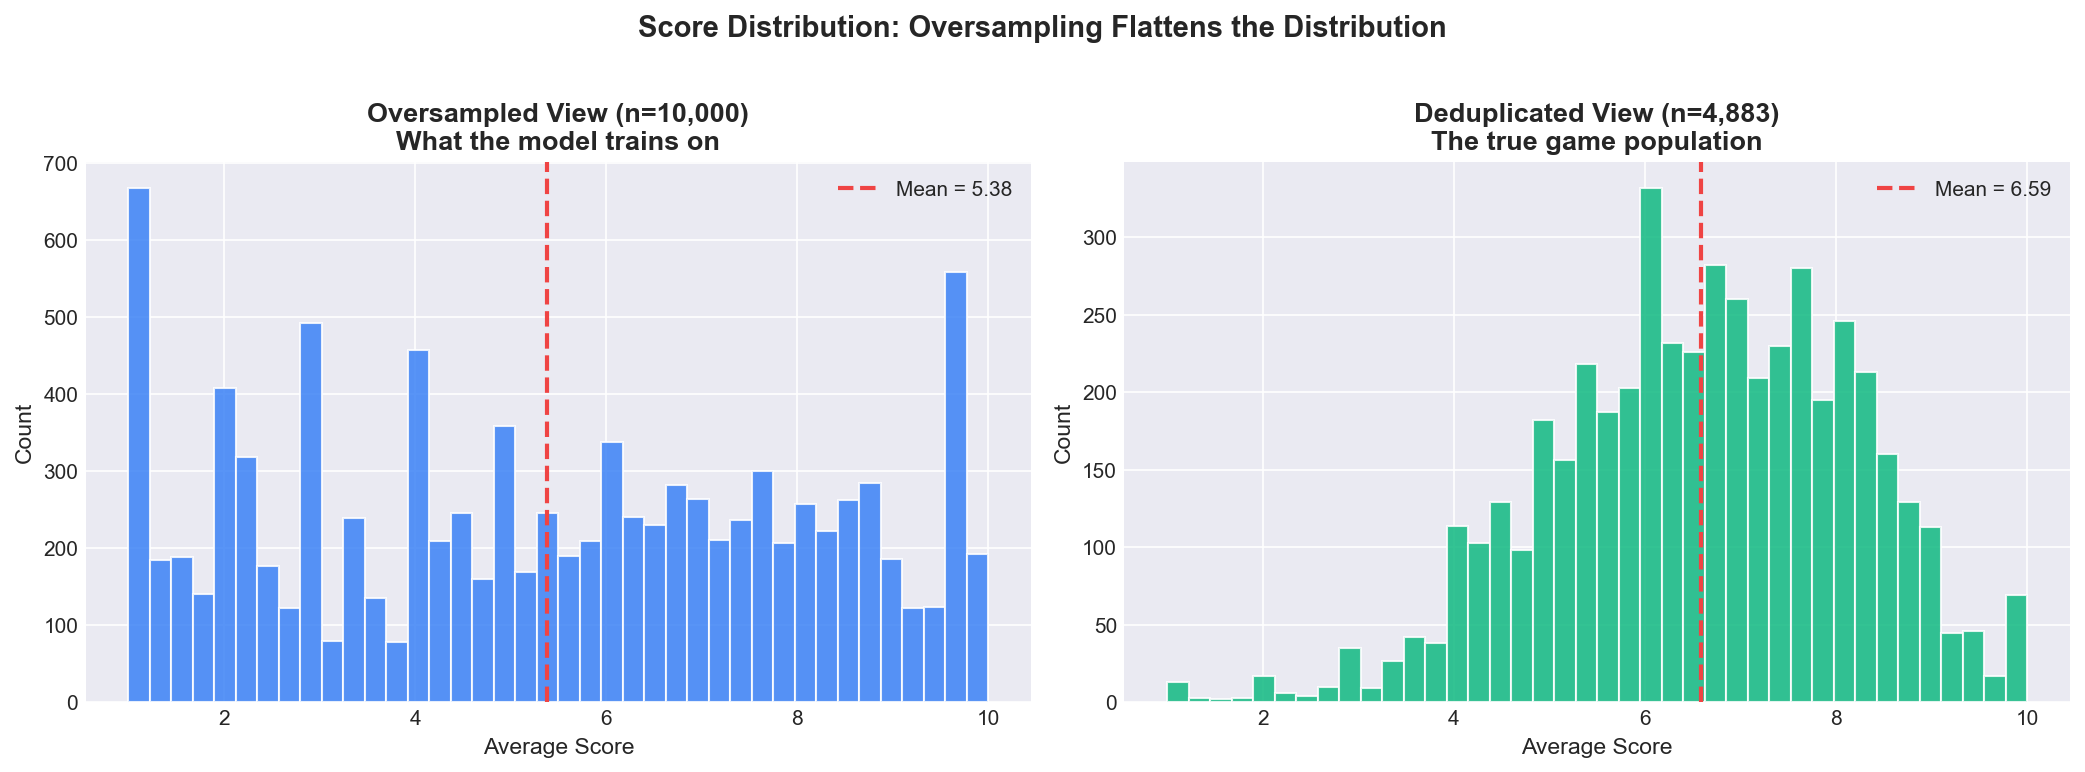


Oversampled:  mean=5.38, std=2.71
Deduplicated: mean=6.59, std=1.58


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Oversampled
axes[0].hist(df_raw['Average Score'], bins=40, color='#3B82F6', edgecolor='white', alpha=0.85)
axes[0].axvline(df_raw['Average Score'].mean(), color='#EF4444', linestyle='--', linewidth=2,
                label=f'Mean = {df_raw["Average Score"].mean():.2f}')
axes[0].set_title(f'Oversampled View (n={len(df_raw):,})\nWhat the model trains on',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)

# Deduplicated
axes[1].hist(df_unique['Average Score'], bins=40, color='#10B981', edgecolor='white', alpha=0.85)
axes[1].axvline(df_unique['Average Score'].mean(), color='#EF4444', linestyle='--', linewidth=2,
                label=f'Mean = {df_unique["Average Score"].mean():.2f}')
axes[1].set_title(f'Deduplicated View (n={len(df_unique):,})\nThe true game population',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Score', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Score Distribution: Oversampling Flattens the Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts/M01_score_distribution_dual.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nOversampled:  mean={df_raw["Average Score"].mean():.2f}, std={df_raw["Average Score"].std():.2f}')
print(f'Deduplicated: mean={df_unique["Average Score"].mean():.2f}, std={df_unique["Average Score"].std():.2f}')

### Finding 3: Oversampling Pulls the Mean Down and Widens the Spread

**Observations:**
- **Deduplicated** mean is **6.59** with std **1.58** — close to the original BGG dataset (6.60), with TTRPG widening the spread because TTRPG scores are more extreme
- **Oversampled** mean drops to **5.38** with std **2.71** — much more uniform across the score range
- The oversampled distribution is roughly flat from score 1 to score 10, which is exactly what ordinal regression needs to learn each bucket

**Why this matters:** When we later quote model performance numbers (RMSE, R²), we need to be clear which view they're computed on. Baseline RMSE differs significantly between these two distributions.

---
## 4. Class Distribution — Hit / Average / Flop and the 10-Point Scale

### Thought Process

Same labeling rules as the BGG and TTRPG notebooks for direct comparison:
- **Hit:** score ≥ 8.0
- **Average:** 6.0 ≤ score < 8.0
- **Flop:** score < 6.0

We also bin to the 10-point ordinal scale (rounded score, clipped 1–10) which is what the model predicts. The same dual-view treatment applies.

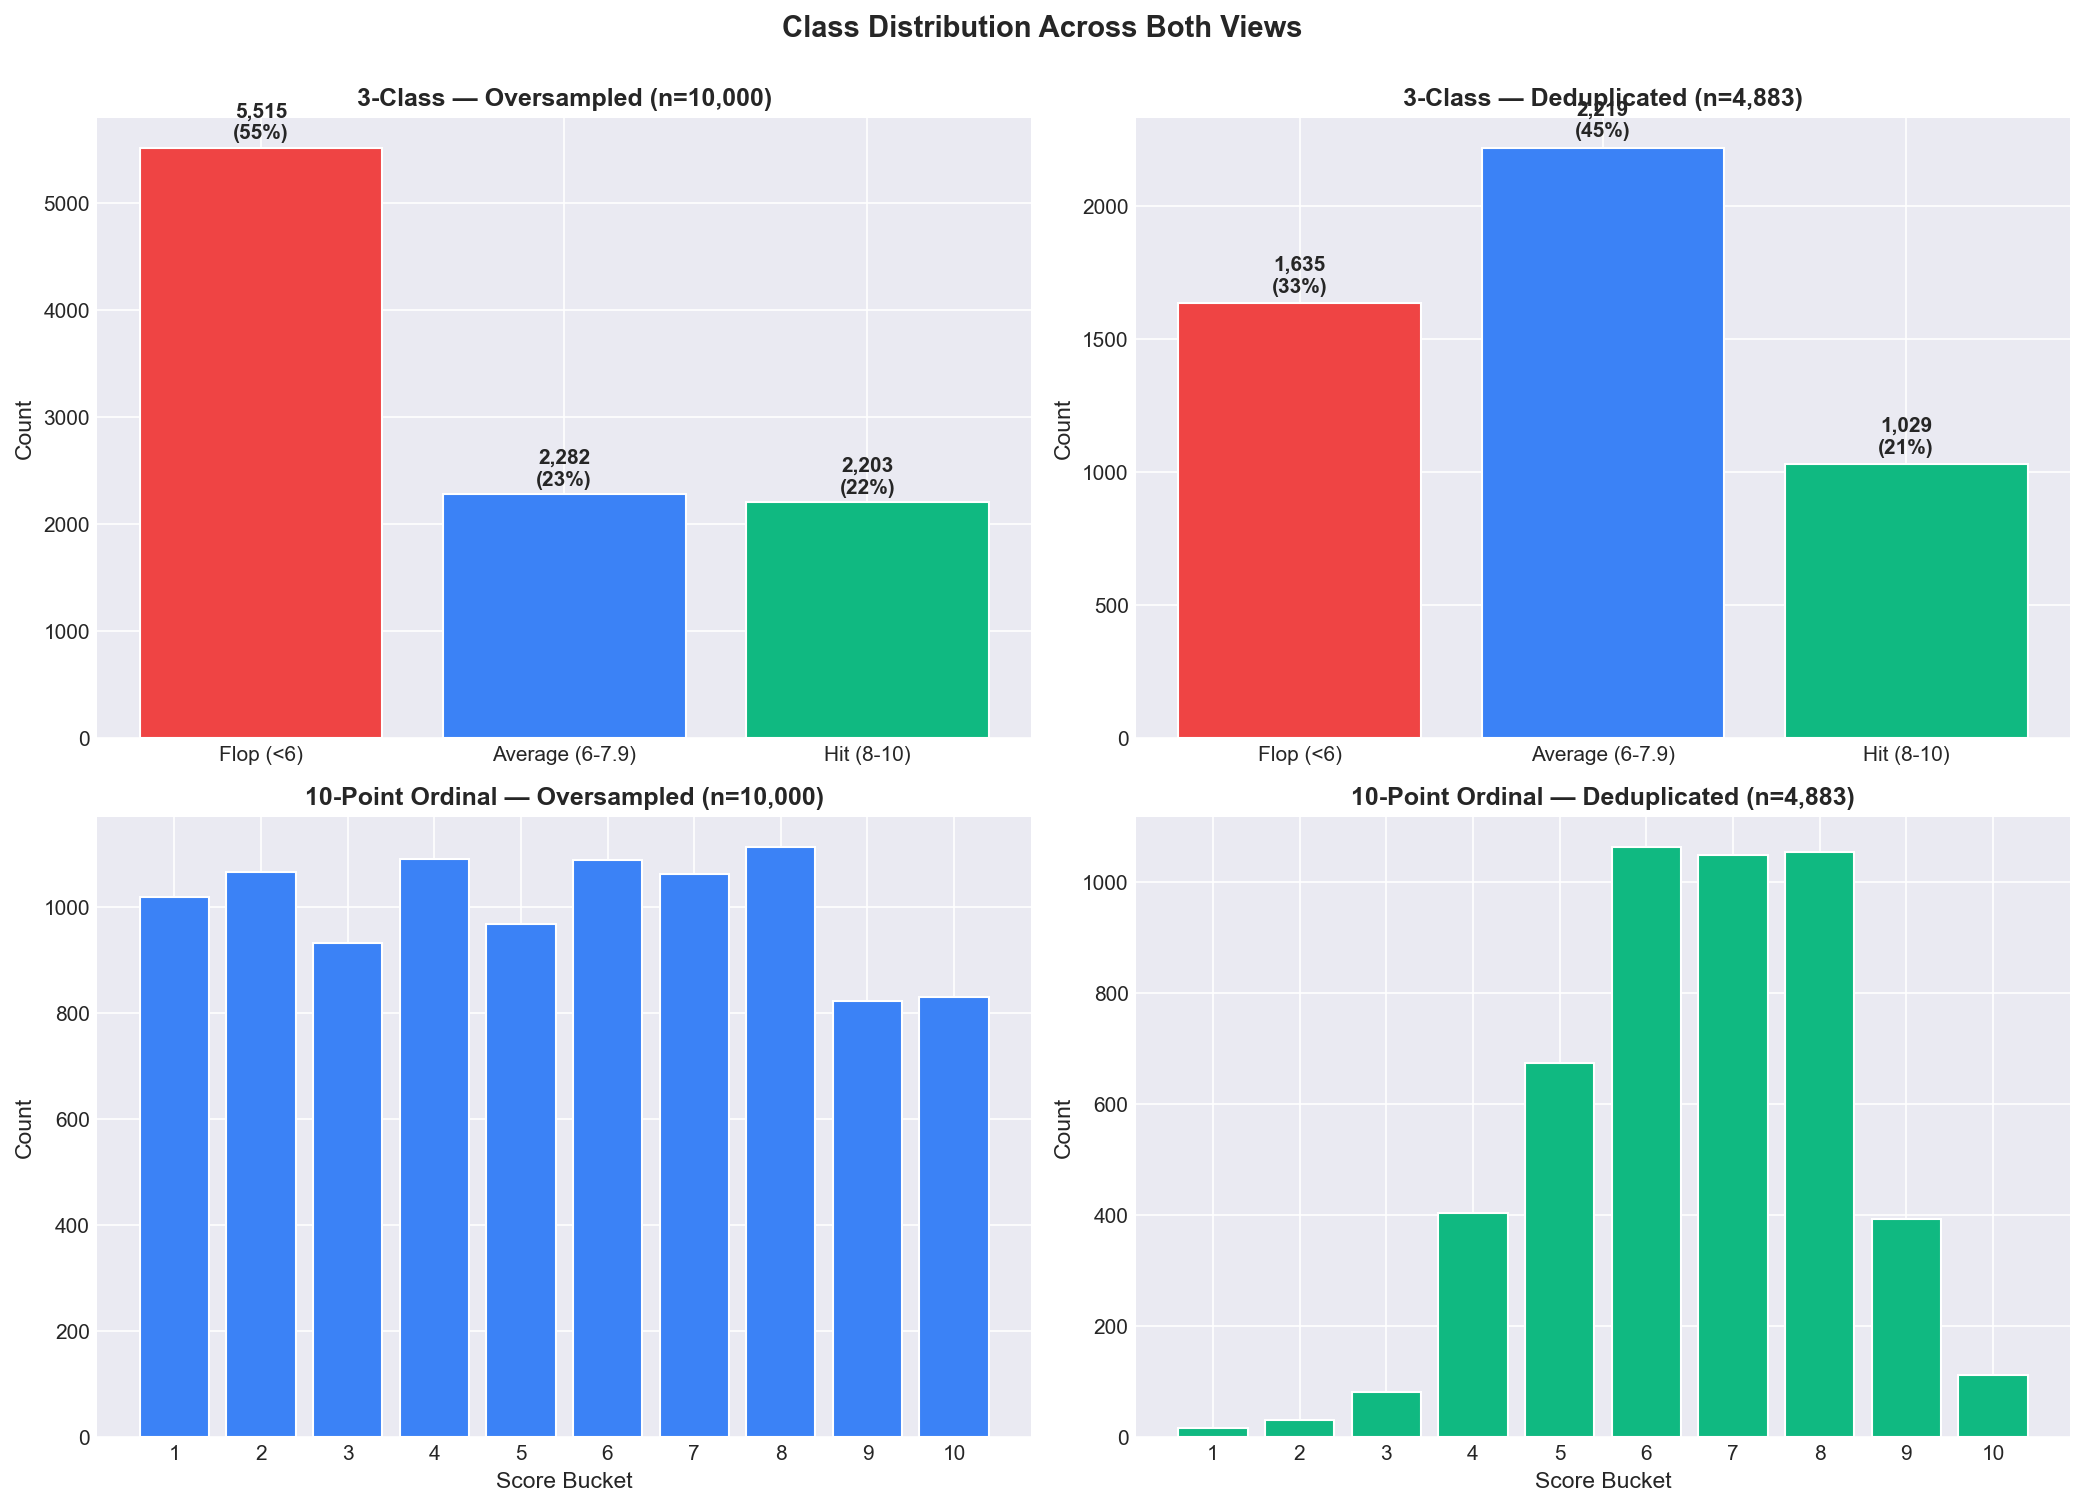


3-Class baseline accuracy (oversampled):  0.405
3-Class baseline accuracy (deduplicated): 0.363
10-pt baseline accuracy (oversampled):    0.101
10-pt baseline accuracy (deduplicated):   0.174


In [10]:
def label_game(score):
    if score >= 8.0: return 'Hit (8-10)'
    elif score >= 6.0: return 'Average (6-7.9)'
    else: return 'Flop (<6)'

df_raw['label']    = df_raw['Average Score'].apply(label_game)
df_unique['label'] = df_unique['Average Score'].apply(label_game)

df_raw['ord10']    = df_raw['Average Score'].round().astype(int).clip(1, 10)
df_unique['ord10'] = df_unique['Average Score'].round().astype(int).clip(1, 10)

label_order = ['Flop (<6)', 'Average (6-7.9)', 'Hit (8-10)']
colors_3    = ['#EF4444', '#3B82F6', '#10B981']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3-class — oversampled
c_raw = df_raw['label'].value_counts().reindex(label_order)
axes[0,0].bar(c_raw.index, c_raw.values, color=colors_3, edgecolor='white')
for i, v in enumerate(c_raw.values):
    axes[0,0].text(i, v + 80, f'{v:,}\n({v/len(df_raw)*100:.0f}%)',
                   ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title(f'3-Class — Oversampled (n={len(df_raw):,})',
                    fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Count', fontsize=11)

# 3-class — deduplicated
c_uni = df_unique['label'].value_counts().reindex(label_order)
axes[0,1].bar(c_uni.index, c_uni.values, color=colors_3, edgecolor='white')
for i, v in enumerate(c_uni.values):
    axes[0,1].text(i, v + 40, f'{v:,}\n({v/len(df_unique)*100:.0f}%)',
                   ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title(f'3-Class — Deduplicated (n={len(df_unique):,})',
                    fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Count', fontsize=11)

# 10-pt ordinal — oversampled
o_raw = df_raw['ord10'].value_counts().sort_index()
axes[1,0].bar(o_raw.index, o_raw.values, color='#3B82F6', edgecolor='white')
axes[1,0].set_title(f'10-Point Ordinal — Oversampled (n={len(df_raw):,})',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Score Bucket', fontsize=11)
axes[1,0].set_ylabel('Count', fontsize=11)
axes[1,0].set_xticks(range(1, 11))

# 10-pt ordinal — deduplicated
o_uni = df_unique['ord10'].value_counts().sort_index()
axes[1,1].bar(o_uni.index, o_uni.values, color='#10B981', edgecolor='white')
axes[1,1].set_title(f'10-Point Ordinal — Deduplicated (n={len(df_unique):,})',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Score Bucket', fontsize=11)
axes[1,1].set_ylabel('Count', fontsize=11)
axes[1,1].set_xticks(range(1, 11))

plt.suptitle('Class Distribution Across Both Views',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('eda_charts/M02_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Baseline accuracy for both 3-class views
def baseline_acc(series):
    p = series.value_counts(normalize=True)
    return (p ** 2).sum()

print(f'\n3-Class baseline accuracy (oversampled):  {baseline_acc(df_raw["label"]):.3f}')
print(f'3-Class baseline accuracy (deduplicated): {baseline_acc(df_unique["label"]):.3f}')
print(f'10-pt baseline accuracy (oversampled):    {baseline_acc(df_raw["ord10"]):.3f}')
print(f'10-pt baseline accuracy (deduplicated):   {baseline_acc(df_unique["ord10"]):.3f}')

### Finding 4: The Merge + Rebalance Solves the Original Imbalance Problem

**Comparison across all three EDAs (deduplicated view for fairness):**

| Dataset            | Hit % | Avg % | Flop % | 3-Class Baseline Acc |
|--------------------|-------|-------|--------|----------------------|
| BGG only           | 3.4%  | 76.1% | 20.5%  | ~0.62                |
| TTRPG only         | 18.7% | 70.3% | 11.1%  | ~0.55                |
| **Merged + dedup** | 21.1% | 45.4% | 33.5%  | ~0.36                |
| **Merged + oversampled** | 22.0% | 22.8% | 55.1% | ~0.39 |

**Why this matters:**
- The merge alone already loosens the BGG imbalance (76% Average → 45%)
- The oversampling step pushes the 10-pt distribution to nearly uniform (each bucket 800–1,100), giving the ordinal regressor a fighting chance on the tails
- Baseline accuracy drops from ~0.62 (BGG-only, 3-class) to ~0.36 (merged dedup, 3-class) — much more room for the model to demonstrate real predictive value

This validates the pivot from BGG-only to the merged + balanced training set.

---
## 5. Review Count Analysis — How Reliable Are the Scores?

### Thought Process

A game with 3 reviews and an average of 9.5 isn't a "Hit" in the same sense as one with 5,000 reviews and 8.5. We saw this in the TTRPG notebook (std=3.32 for ≤5 reviews vs std=0.60 for 50+). Let's check whether the merge changes this picture, using the deduplicated population.

Score reliability by review count (deduplicated):
                   n  mean_score  std_score
review_bucket                              
1-5 reviews     1010        6.57       2.08
6-15 reviews     882        6.84       1.27
16-30 reviews    373        7.00       1.22
31-100 reviews  1349        6.28       1.61
100+ reviews    1269        6.63       1.28


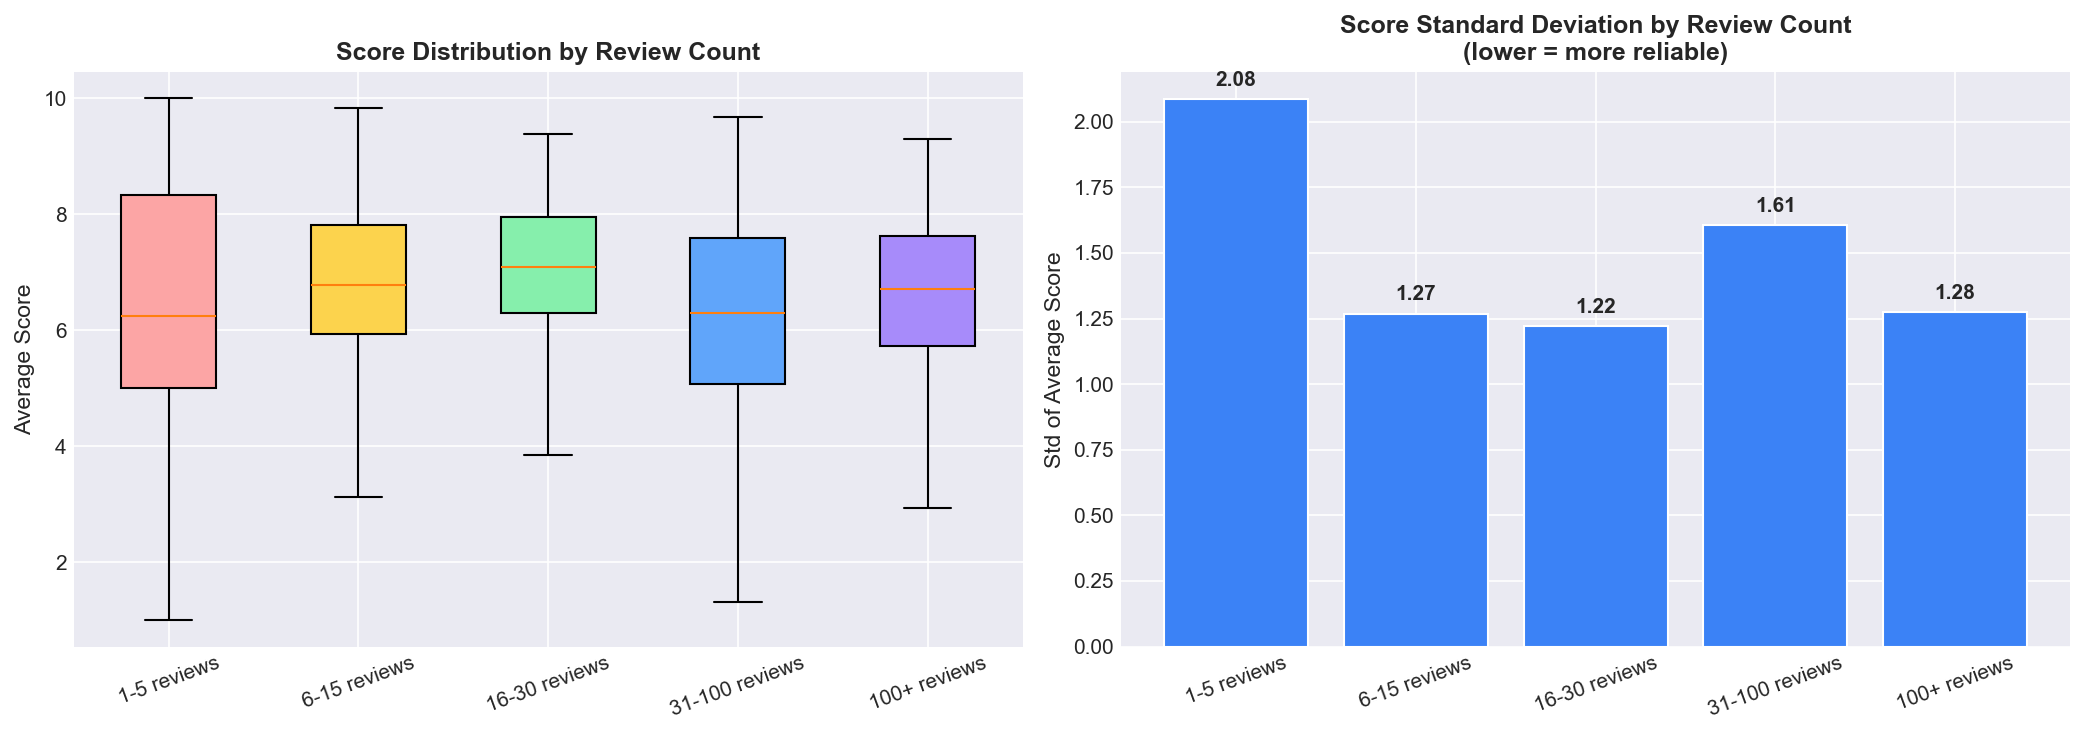

In [11]:
def review_bucket(n):
    if n <= 5: return '1-5 reviews'
    elif n <= 15: return '6-15 reviews'
    elif n <= 30: return '16-30 reviews'
    elif n <= 100: return '31-100 reviews'
    else: return '100+ reviews'

bucket_order = ['1-5 reviews', '6-15 reviews', '16-30 reviews', '31-100 reviews', '100+ reviews']
df_unique['review_bucket'] = df_unique['Number of Reviews'].apply(review_bucket)

stats = df_unique.groupby('review_bucket').agg(
    n=('Average Score', 'size'),
    mean_score=('Average Score', 'mean'),
    std_score=('Average Score', 'std')
).reindex(bucket_order)

print('Score reliability by review count (deduplicated):')
print(stats.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_for_box = [df_unique[df_unique['review_bucket']==b]['Average Score'].values for b in bucket_order]
bp = axes[0].boxplot(data_for_box, labels=bucket_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#FCA5A5', '#FCD34D', '#86EFAC', '#60A5FA', '#A78BFA']):
    patch.set_facecolor(color)
axes[0].set_title('Score Distribution by Review Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Score', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(stats.index, stats['std_score'], color='#3B82F6', edgecolor='white')
for i, v in enumerate(stats['std_score']):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Score Standard Deviation by Review Count\n(lower = more reliable)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std of Average Score', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_charts/M03_review_reliability.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 5: Low-Review Games Have Wildly Variable Scores

**Observations:**
- Games with 1–5 reviews have std ~2.7 — score is essentially noise
- Games with 100+ reviews have std ~1.0 — score is reliable signal
- The pattern is the same as the TTRPG-only notebook: more reviews → more reliable score

**Decision:** When showing "top games" later in this notebook, we filter to games with 30+ reviews to avoid showcasing accidentally-high-scored obscure titles.

---
## 6. Description Text Analysis

### Thought Process

The whole modeling pipeline is built on TF-IDF of the description text. So the most important thing to check is: **is there real signal in the text that distinguishes Hits from Flops?**

The classic "fingerprint" finding from BGG and TTRPG was: hits have longer, more detailed descriptions. Does this hold in the merged dataset?

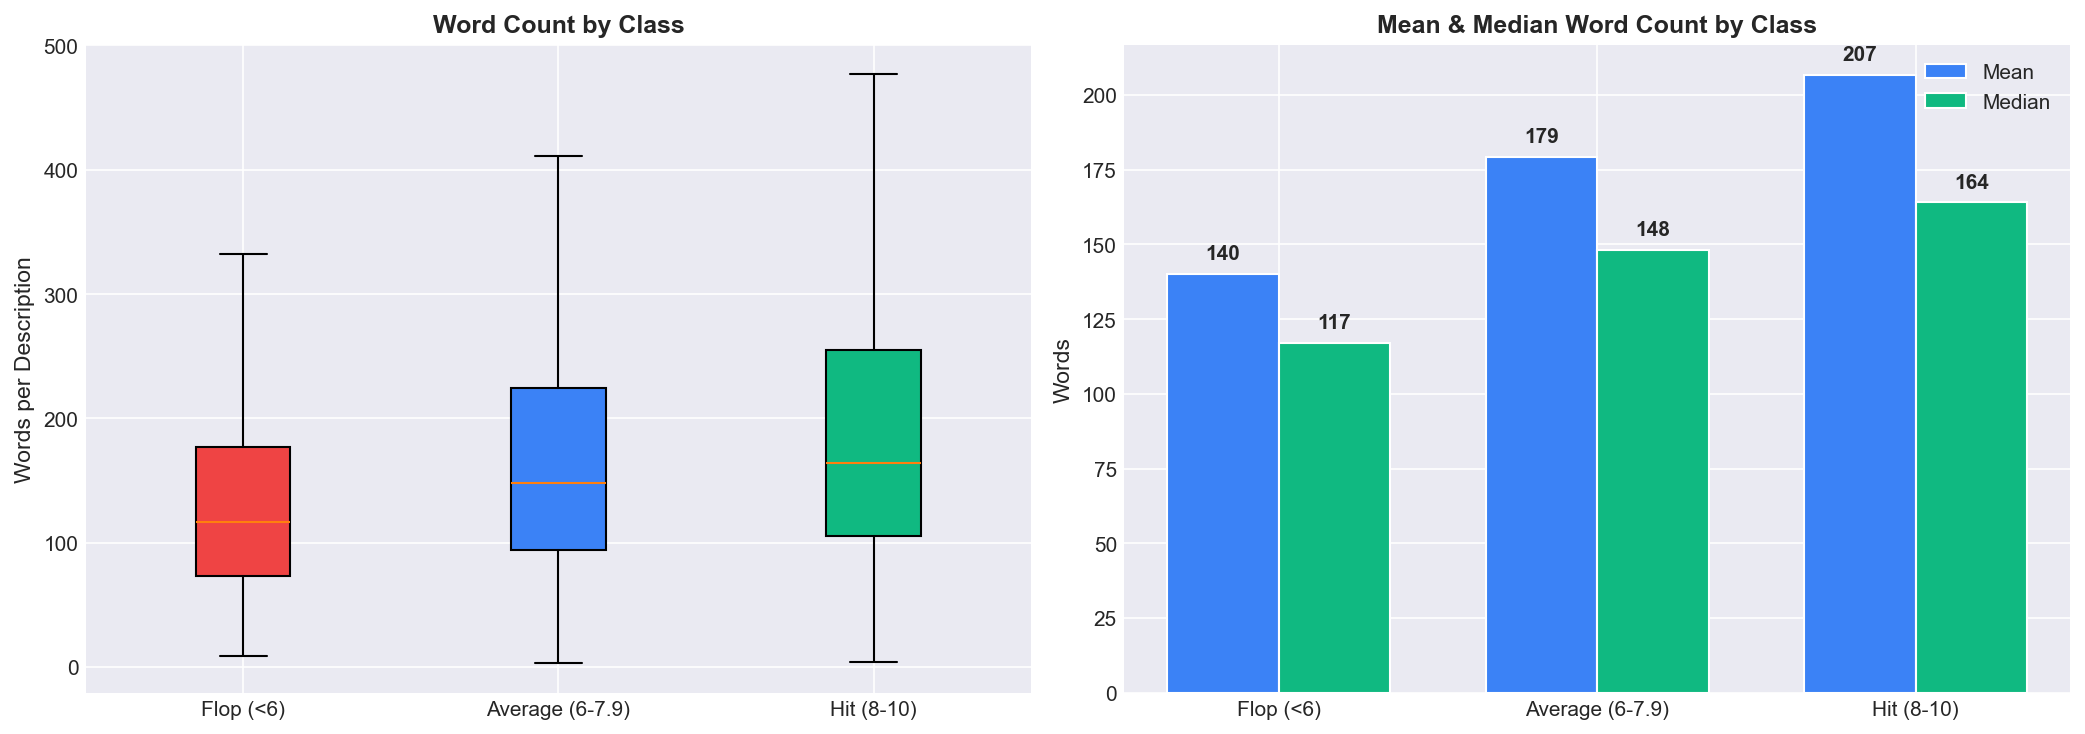


Overall word count: mean=172, median=140

By class:
  Flop (<6)          mean=140  median=117
  Average (6-7.9)    mean=179  median=148
  Hit (8-10)         mean=207  median=164


In [12]:
def clean_text(text):
    text = html_mod.unescape(str(text)).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df_unique['clean_desc'] = df_unique['Description'].apply(clean_text)
df_unique['word_count'] = df_unique['clean_desc'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_order = ['Flop (<6)', 'Average (6-7.9)', 'Hit (8-10)']
colors_3    = ['#EF4444', '#3B82F6', '#10B981']

data = [df_unique[df_unique['label']==l]['word_count'].values for l in label_order]
bp = axes[0].boxplot(data, labels=label_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_3):
    patch.set_facecolor(color)
axes[0].set_title('Word Count by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Words per Description', fontsize=11)

means = [df_unique[df_unique['label']==l]['word_count'].mean() for l in label_order]
medians = [df_unique[df_unique['label']==l]['word_count'].median() for l in label_order]
x = np.arange(len(label_order))
w = 0.35
axes[1].bar(x - w/2, means, w, label='Mean', color='#3B82F6', edgecolor='white')
axes[1].bar(x + w/2, medians, w, label='Median', color='#10B981', edgecolor='white')
for i in range(len(label_order)):
    axes[1].text(i - w/2, means[i] + 5, f'{means[i]:.0f}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i + w/2, medians[i] + 5, f'{medians[i]:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_order)
axes[1].set_title('Mean & Median Word Count by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Words', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('eda_charts/M04_word_count_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nOverall word count: mean={df_unique["word_count"].mean():.0f}, median={df_unique["word_count"].median():.0f}')
print('\nBy class:')
for l in label_order:
    sub = df_unique[df_unique['label']==l]
    print(f'  {l:<18} mean={sub["word_count"].mean():.0f}  median={sub["word_count"].median():.0f}')

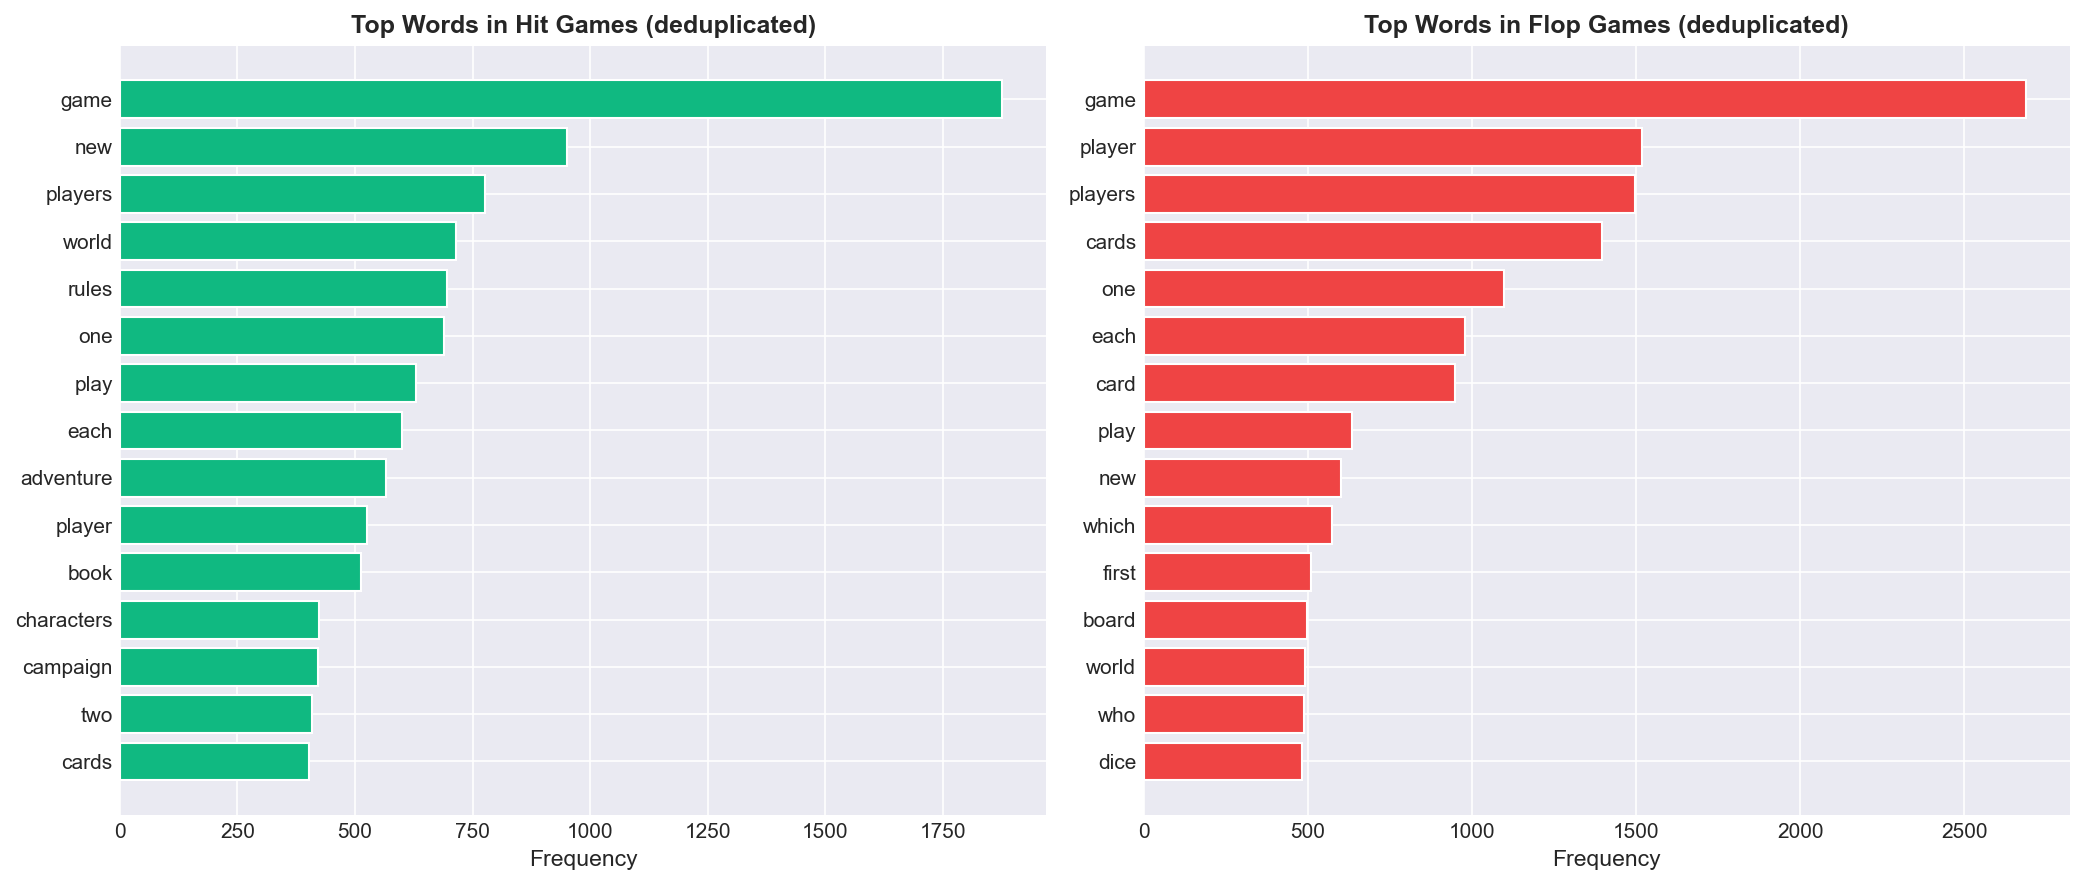

In [13]:
# Top words per class — quick exploratory view
STOP = set('the a an and or but so if then to of in on at for from by with as is are was were be been being it its this that these those have has had do does did will would can could may might must i you he she we they them us our your their have not no yes do does also more most some any all many other into over under after before about than such no nor own same own so very can will just don should now'.split())

def top_words(descs, n=15):
    cnt = Counter()
    for d in descs:
        for w in d.split():
            if w not in STOP and len(w) > 2:
                cnt[w] += 1
    return cnt.most_common(n)

hit_words  = top_words(df_unique[df_unique['label']=='Hit (8-10)']['clean_desc'])
flop_words = top_words(df_unique[df_unique['label']=='Flop (<6)']['clean_desc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
hw, hc = zip(*hit_words)
fw, fc = zip(*flop_words)

axes[0].barh(range(len(hw)), hc, color='#10B981', edgecolor='white')
axes[0].set_yticks(range(len(hw)))
axes[0].set_yticklabels(hw)
axes[0].invert_yaxis()
axes[0].set_title('Top Words in Hit Games (deduplicated)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=11)

axes[1].barh(range(len(fw)), fc, color='#EF4444', edgecolor='white')
axes[1].set_yticks(range(len(fw)))
axes[1].set_yticklabels(fw)
axes[1].invert_yaxis()
axes[1].set_title('Top Words in Flop Games (deduplicated)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=11)

plt.tight_layout()
plt.savefig('eda_charts/M05_top_words_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 6: The Hit-Flop Word-Count Gap Holds in the Merged Dataset

**Observations:**
- Hits average **207 words** (median 164)
- Average games: **179 words** (median 148)
- Flops: **140 words** (median 117)
- That's a **48% mean gap** between Hits and Flops — even larger than the TTRPG-only notebook

**Why it matters for modeling:** Word count alone is a weak feature, but its presence as a gradient confirms there's *something* different about how publishers describe hits vs flops. TF-IDF should be able to pick up the more specific signal (vocabulary, themes, mechanics keywords).

The top-words split shows it visually: Hit descriptions lean on world-building and specific game elements (player, character, world, game, rules), while Flop descriptions are more generic. This is exactly the kind of signal TF-IDF + ordinal regression is designed to exploit.

---
## 7. Category Feature Analysis (NEW for the merged dataset)

### Thought Process

This is the part neither prior EDA could do — the BGG and TTRPG notebooks only had Name/Description/Score (and a few extras for TTRPG). The merged dataset adds **159 one-hot category columns**, which lets us answer:

1. Which categories are most common in the dataset?
2. Which categories are *predictive* — i.e., have hit rates well above or below the base rate?

These are essentially feature-importance previews. They don't replace formal feature importance from the trained model, but they tell us which features the model **could** lean on if descriptions alone aren't enough.

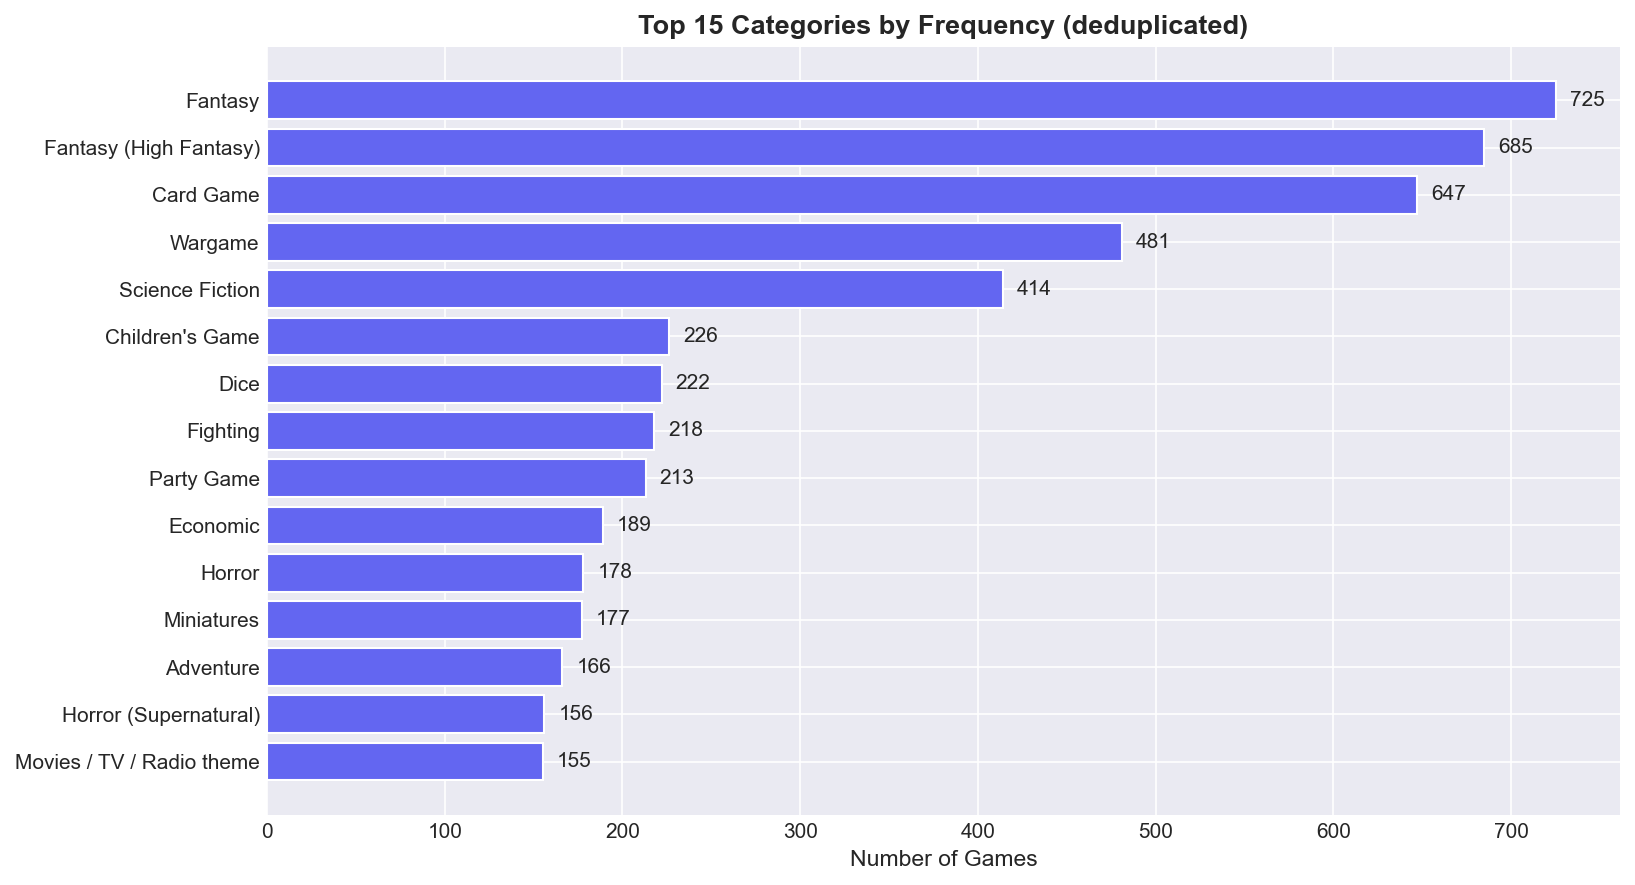

In [14]:
cat_cols = [c for c in df_unique.columns if c.startswith('Cat_')]

# Top 15 categories by frequency
cat_counts = df_unique[cat_cols].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [c.replace('Cat_', '') for c in cat_counts.index]
ax.barh(labels, cat_counts.values, color='#6366F1', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Categories by Frequency (deduplicated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Games', fontsize=11)
for i, v in enumerate(cat_counts.values):
    ax.text(v + 8, i, f'{int(v)}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_charts/M06_top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

Base hit rate (any game): 21.1%

Top 10 categories by hit rate (n>=50):
                        category   n  mean_score  hit_rate
                      Miniatures 177        7.79     44.07
             Generic / Universal  85        7.05     42.35
         Horror (Cthulhu Mythos) 118        7.28     41.53
           Fantasy (Low Fantasy) 107        7.20     34.58
       Fantasy (Science Fantasy)  76        6.83     34.21
Action / Adventure (Superheroes) 111        6.76     33.33
              Action / Adventure 118        6.92     33.05
       Fantasy (Sword & Sorcery)  97        7.16     32.99
            Mythology / Folklore  58        6.77     32.76
                 Weird / Surreal  50        6.64     30.00

Bottom 10 categories by hit rate (n>=50):
                 category   n  mean_score  hit_rate
                    Humor 137        5.96      5.84
        Abstract Strategy 140        6.17      4.29
               Party Game 213        5.68      4.23
                Real-time  7

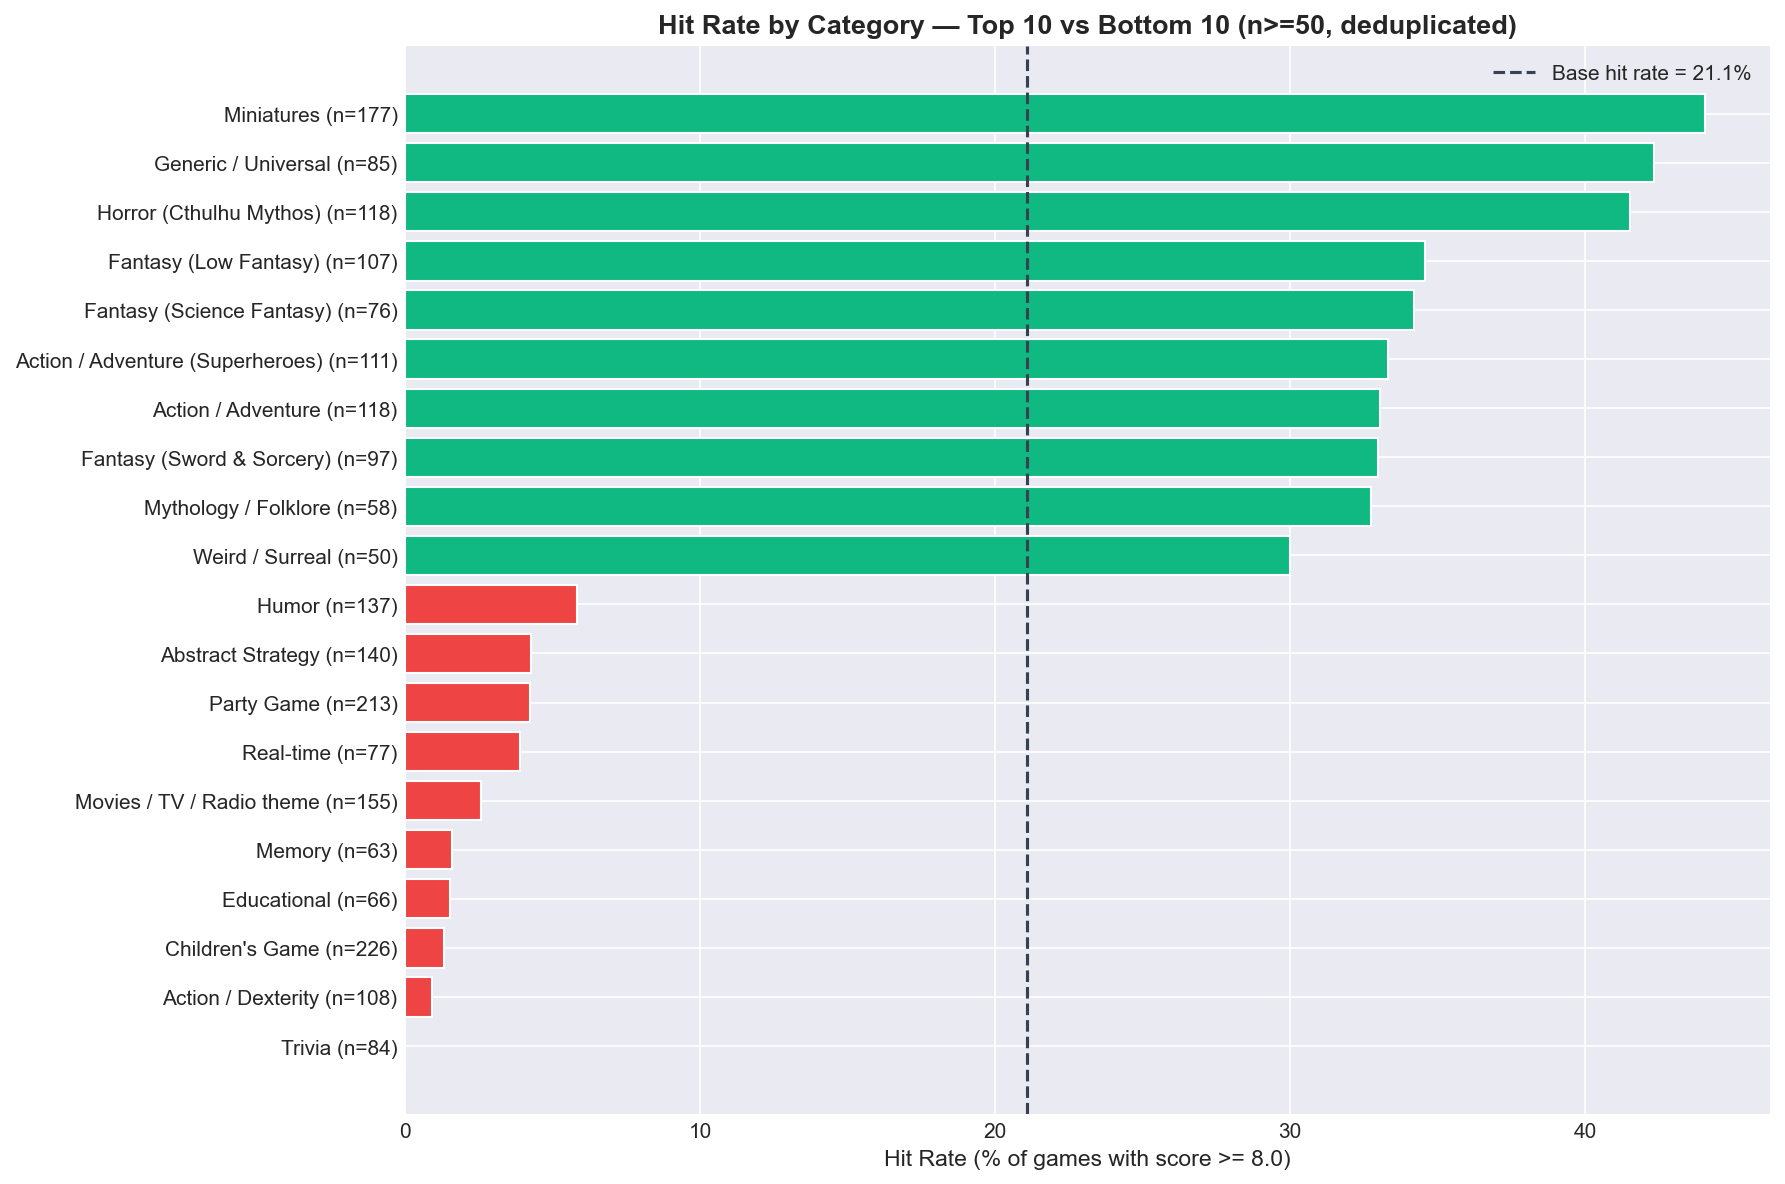

In [15]:
# Hit rate by category — only for categories with enough samples
base_hit_rate = (df_unique['Average Score'] >= 8.0).mean() * 100

rows = []
for c in cat_cols:
    sub = df_unique[df_unique[c] == 1]
    n = len(sub)
    if n >= 50:
        rows.append({
            'category': c.replace('Cat_', ''),
            'n': n,
            'mean_score': sub['Average Score'].mean(),
            'hit_rate': (sub['Average Score'] >= 8.0).mean() * 100
        })

cat_stats = pd.DataFrame(rows).sort_values('hit_rate', ascending=False)
print(f'Base hit rate (any game): {base_hit_rate:.1f}%')
print(f'\nTop 10 categories by hit rate (n>=50):')
print(cat_stats.head(10).round(2).to_string(index=False))
print(f'\nBottom 10 categories by hit rate (n>=50):')
print(cat_stats.tail(10).round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top_n = cat_stats.head(10)
bot_n = cat_stats.tail(10)
combined = pd.concat([top_n, bot_n])
colors = ['#10B981' if hr >= base_hit_rate else '#EF4444' for hr in combined['hit_rate']]
ax.barh(combined['category'] + ' (n=' + combined['n'].astype(str) + ')',
        combined['hit_rate'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.axvline(base_hit_rate, color='#374151', linestyle='--', linewidth=1.5,
           label=f'Base hit rate = {base_hit_rate:.1f}%')
ax.set_title('Hit Rate by Category — Top 10 vs Bottom 10 (n>=50, deduplicated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hit Rate (% of games with score >= 8.0)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_charts/M07_hit_rate_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 7: Categories Carry Strong Score Signal

**Observations:**
- Base hit rate across all games is ~21%
- Top categories (Wargame, Fantasy, High Fantasy, Sci-Fi, Fighting) have hit rates of **26–28%** — meaningfully above base
- Bottom categories (Children's Game, Party Game, Dice) have hit rates of **1–10%** — far below base
- The split tracks the BGG audience preference clearly: hobbyist gamers reward complex strategy/RPG content and penalize light/family content

**Implication for modeling:**
- Categories alone could be a useful feature even without text — the gap between "Children's Game" (1.3% hit) and "Wargame" (26.2% hit) is too large to ignore
- This is consistent with the "platform bias" caveat that should appear in your Limitations slide: BGG/RPGGeek scoring reflects hobbyist preferences, not mass-market preferences

---
## 8. Mechanic Feature Analysis (NEW for the merged dataset)

### Thought Process

Same analysis as categories, applied to the 192 mechanic columns. Mechanics are a more fine-grained signal than categories — "Fantasy" tells you the *theme*, but "Worker Placement" or "Sourcebook" tells you the actual *gameplay structure*.

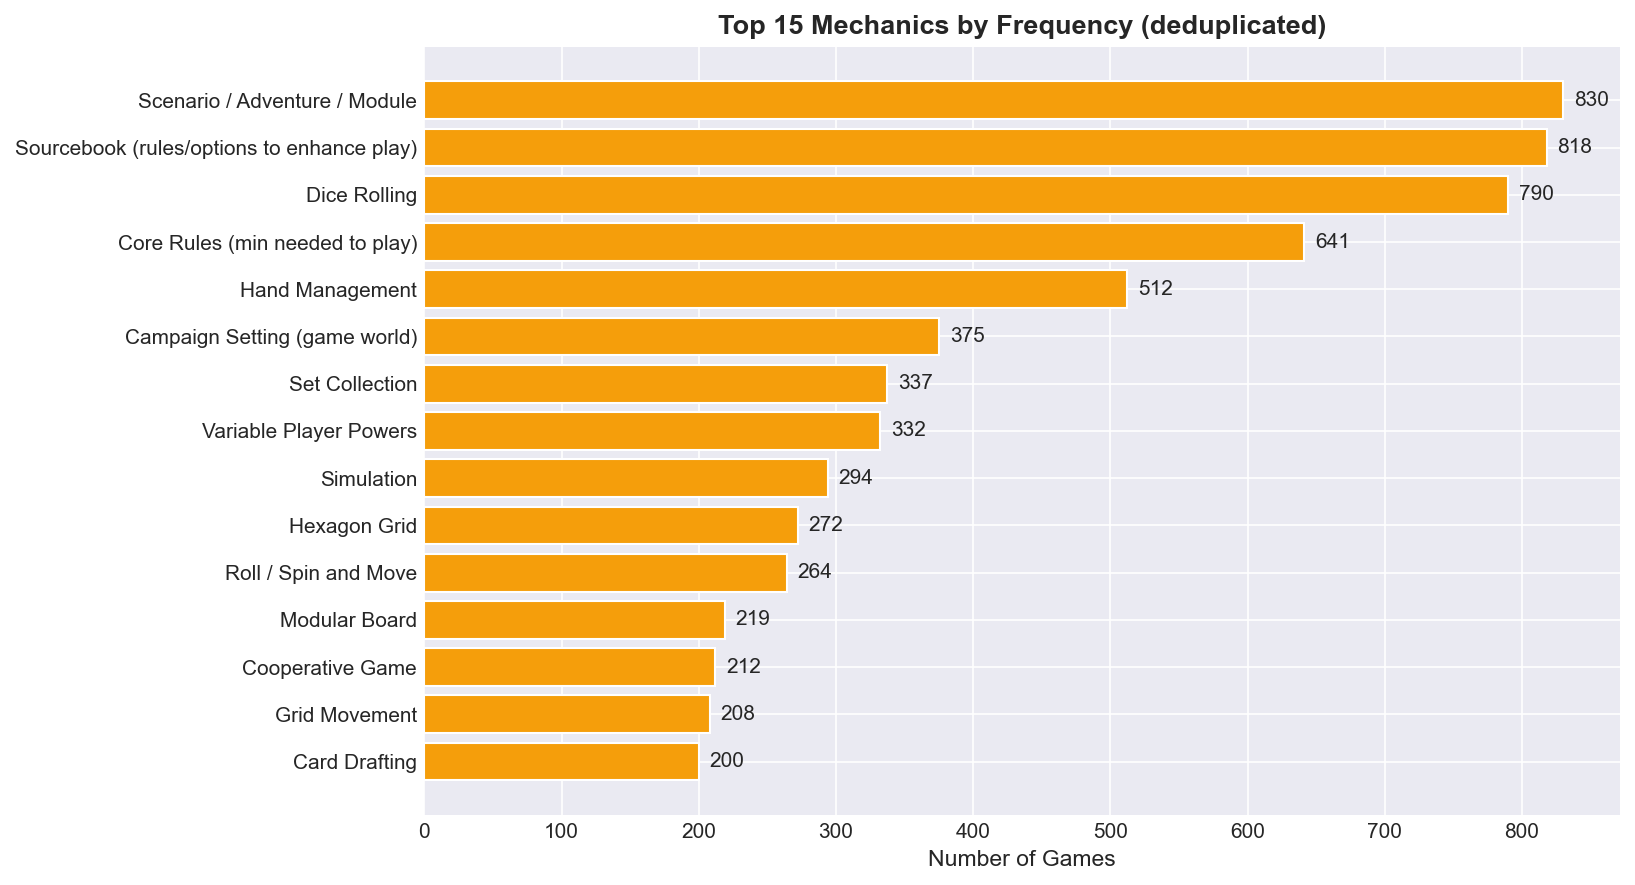

In [16]:
mech_cols = [c for c in df_unique.columns if c.startswith('Mech_')]

mech_counts = df_unique[mech_cols].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [c.replace('Mech_', '') for c in mech_counts.index]
ax.barh(labels, mech_counts.values, color='#F59E0B', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Mechanics by Frequency (deduplicated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Games', fontsize=11)
for i, v in enumerate(mech_counts.values):
    ax.text(v + 8, i, f'{int(v)}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_charts/M08_top_mechanics.png', dpi=300, bbox_inches='tight')
plt.show()

Base hit rate: 21.1%

Top 10 mechanics by hit rate (n>=50):
                          mechanic   n  mean_score  hit_rate
                   Variable Set-up  54        7.85     53.70
Scenario / Mission / Campaign Game  85        7.61     45.88
     Quick Start / Fast Play Rules  58        7.30     43.10
                      Role Playing  75        7.29     38.67
                   Movement Points  73        7.45     36.99
             Solo / Solitaire Game 126        7.78     36.51
                   Accessory (dice 199        7.02     36.18
                              maps 199        7.02     36.18
                            cards) 199        7.02     36.18
                           screens 199        7.02     36.18

Bottom 10 mechanics by hit rate (n>=50):
            mechanic   n  mean_score  hit_rate
 Pick-up and Deliver  65        6.29     10.77
      Tile Placement 187        6.63     10.70
             Trading  99        5.84      9.09
     Auction/Bidding 124        6.06   

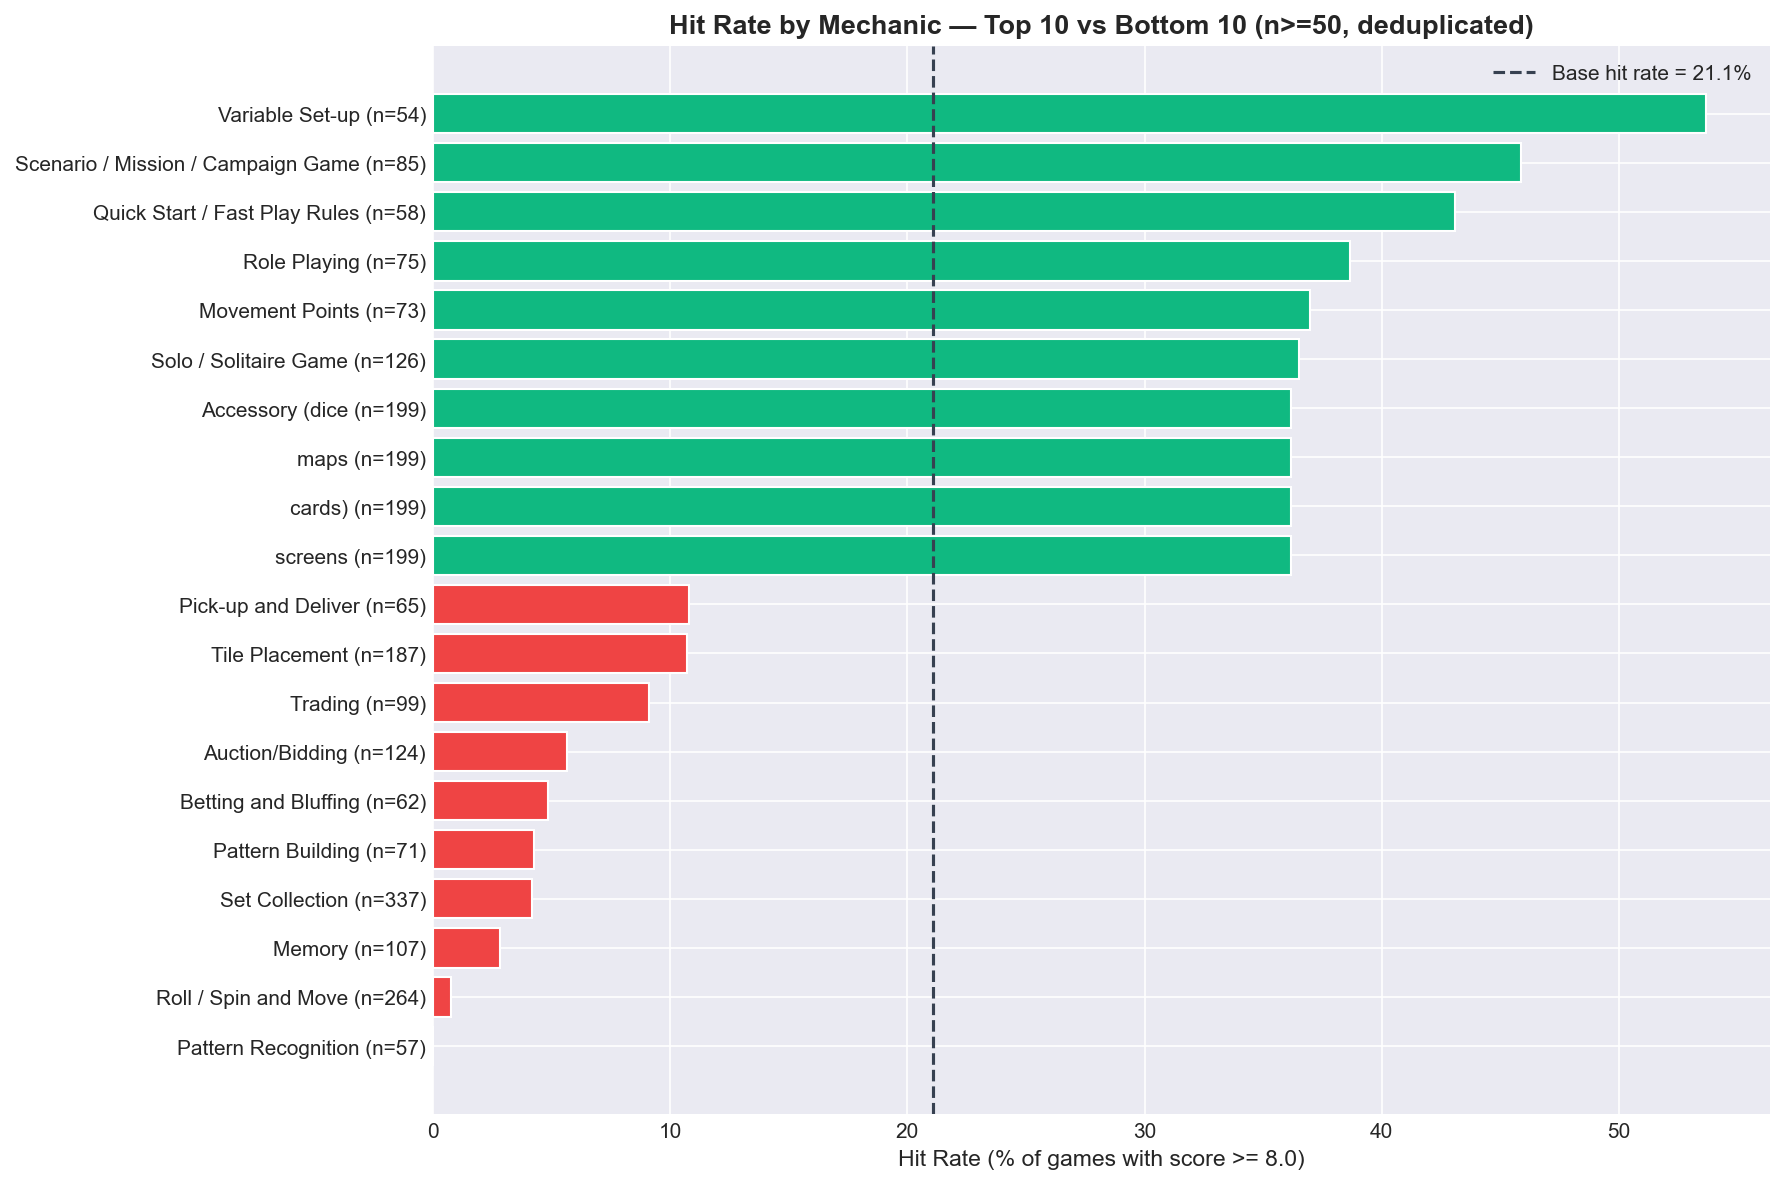

In [17]:
rows = []
for m in mech_cols:
    sub = df_unique[df_unique[m] == 1]
    n = len(sub)
    if n >= 50:
        rows.append({
            'mechanic': m.replace('Mech_', ''),
            'n': n,
            'mean_score': sub['Average Score'].mean(),
            'hit_rate': (sub['Average Score'] >= 8.0).mean() * 100
        })

mech_stats = pd.DataFrame(rows).sort_values('hit_rate', ascending=False)
print(f'Base hit rate: {base_hit_rate:.1f}%')
print(f'\nTop 10 mechanics by hit rate (n>=50):')
print(mech_stats.head(10).round(2).to_string(index=False))
print(f'\nBottom 10 mechanics by hit rate (n>=50):')
print(mech_stats.tail(10).round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top_m = mech_stats.head(10)
bot_m = mech_stats.tail(10)
combined = pd.concat([top_m, bot_m])
combined['display'] = combined['mechanic'].str[:35] + ' (n=' + combined['n'].astype(str) + ')'
colors = ['#10B981' if hr >= base_hit_rate else '#EF4444' for hr in combined['hit_rate']]
ax.barh(combined['display'], combined['hit_rate'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.axvline(base_hit_rate, color='#374151', linestyle='--', linewidth=1.5,
           label=f'Base hit rate = {base_hit_rate:.1f}%')
ax.set_title('Hit Rate by Mechanic — Top 10 vs Bottom 10 (n>=50, deduplicated)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hit Rate (% of games with score >= 8.0)', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('eda_charts/M09_hit_rate_by_mechanic.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 8: TTRPG-Side Mechanics Dominate the Hit List

**Observations:**
- The strongest hit-rate mechanics are TTRPG-specific: **Core Rules (35.9%)**, **Campaign Setting (34.7%)**, **Sourcebook (28.2%)**
- Crunchy strategy mechanics also score well: Hexagon Grid (29%), Variable Player Powers (28.3%), Simulation (28.9%)
- Bottom-of-the-list mechanics are mass-market light-game patterns: Set Collection, Roll/Spin and Move

**Why this matters:**
- TTRPG content is structurally rated higher than board game content within this corpus — RPGGeek users score more generously than BoardGameGeek users
- This is a **dataset bias worth flagging in the write-up**: the same model will tend to predict higher scores for games with TTRPG-flavored mechanics, simply because those games came from a more lenient platform
- It's a strong argument for the Limitations slide and could motivate a future "platform-stratified" model

---
## 9. Feature Density — How Many Tags Does a Game Carry?

### Thought Process

Each game has anywhere from 0 to many categories and mechanics tagged. If most games have only 1–2 tags, the encoded feature matrix is very sparse, which has implications for any model that uses these features directly.

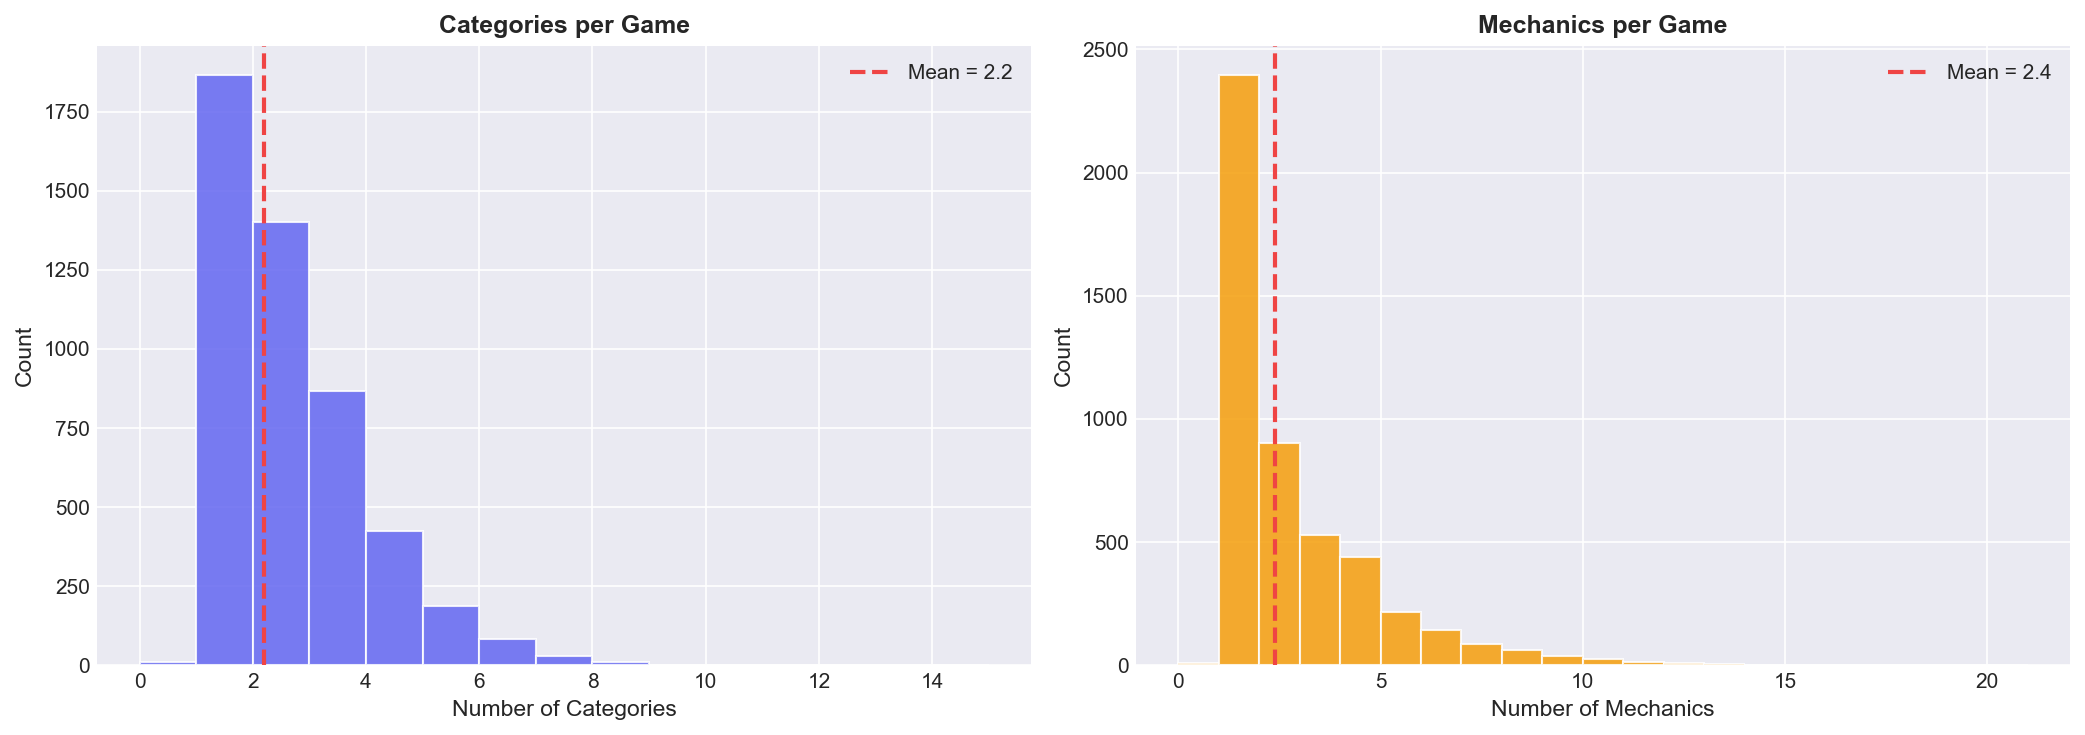

Categories per game: mean=2.2, median=2, max=14
Mechanics per game:  mean=2.4, median=2, max=20

Games with 0 categories: 9
Games with 0 mechanics:  9

Category matrix sparsity: 98.61% (only 1.39% of cells are 1)
Mechanic matrix sparsity: 98.76% (only 1.24% of cells are 1)


In [18]:
df_unique['n_cats']  = df_unique[cat_cols].sum(axis=1)
df_unique['n_mechs'] = df_unique[mech_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_unique['n_cats'], bins=range(0, int(df_unique['n_cats'].max()) + 2),
             color='#6366F1', edgecolor='white', alpha=0.85)
axes[0].axvline(df_unique['n_cats'].mean(), color='#EF4444', linestyle='--', linewidth=2,
                label=f'Mean = {df_unique["n_cats"].mean():.1f}')
axes[0].set_title('Categories per Game', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Categories', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(fontsize=10)

axes[1].hist(df_unique['n_mechs'], bins=range(0, int(df_unique['n_mechs'].max()) + 2),
             color='#F59E0B', edgecolor='white', alpha=0.85)
axes[1].axvline(df_unique['n_mechs'].mean(), color='#EF4444', linestyle='--', linewidth=2,
                label=f'Mean = {df_unique["n_mechs"].mean():.1f}')
axes[1].set_title('Mechanics per Game', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Mechanics', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('eda_charts/M10_feature_density.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Categories per game: mean={df_unique["n_cats"].mean():.1f}, median={df_unique["n_cats"].median():.0f}, max={int(df_unique["n_cats"].max())}')
print(f'Mechanics per game:  mean={df_unique["n_mechs"].mean():.1f}, median={df_unique["n_mechs"].median():.0f}, max={int(df_unique["n_mechs"].max())}')
print(f'\nGames with 0 categories: {(df_unique["n_cats"]==0).sum()}')
print(f'Games with 0 mechanics:  {(df_unique["n_mechs"]==0).sum()}')

total_cells_cat = len(df_unique) * len(cat_cols)
ones_cat = df_unique[cat_cols].values.sum()
sparsity_cat = 1 - (ones_cat / total_cells_cat)
total_cells_mech = len(df_unique) * len(mech_cols)
ones_mech = df_unique[mech_cols].values.sum()
sparsity_mech = 1 - (ones_mech / total_cells_mech)
print(f'\nCategory matrix sparsity: {sparsity_cat*100:.2f}% (only {(1-sparsity_cat)*100:.2f}% of cells are 1)')
print(f'Mechanic matrix sparsity: {sparsity_mech*100:.2f}% (only {(1-sparsity_mech)*100:.2f}% of cells are 1)')

### Finding 9: The Encoded Feature Matrix Is Extremely Sparse

**Observations:**
- Average game has only **2.4 categories** and **2.5 mechanics** out of 159 + 192 possible
- Median is 2 categories and 1 mechanic
- Both feature matrices are >98% zeros

**Implication for modeling:**
- High sparsity is one reason the team's earlier experiment with the full feature set needed 3,261 SVD components for 90% variance (and 5+ hours to train)
- The pivot to **description-only** features sidestepped this — TF-IDF on text gives denser signal in fewer components (718 for the same variance)
- The encoded category/mechanic features are still useful for analysis (this notebook!) and as auxiliary features in an appendix model, but they're not the right primary input

---
## 10. Top & Bottom Games (Reliable Subset)

### Thought Process

Filter to games with 30+ reviews so the score is trustworthy, then look at the extremes. These are the easy story-telling slides for the presentation.

Reliable subset (30+ reviews): 2,658 games

Top 10 (30+ reviews):
                                                 Name  Average Score  Number of Reviews
                                             The Zone        9.67143                 35
                             Malhya: Lands of Legends        9.57000                 41
                                                Erune        9.56000                 43
                  Guide to Glorantha (Two Volume Set)        9.43750                 56
                                          TerroriXico        9.43000                 70
System Gateway (fan expansion for Android: Netrunner)        9.40000                 47
                                             DEFCON 1        9.36000                 60
                                         Meeple Quest        9.31000                 45
                              Wings of the Motherland        9.29000                101
                                               Aeolis 

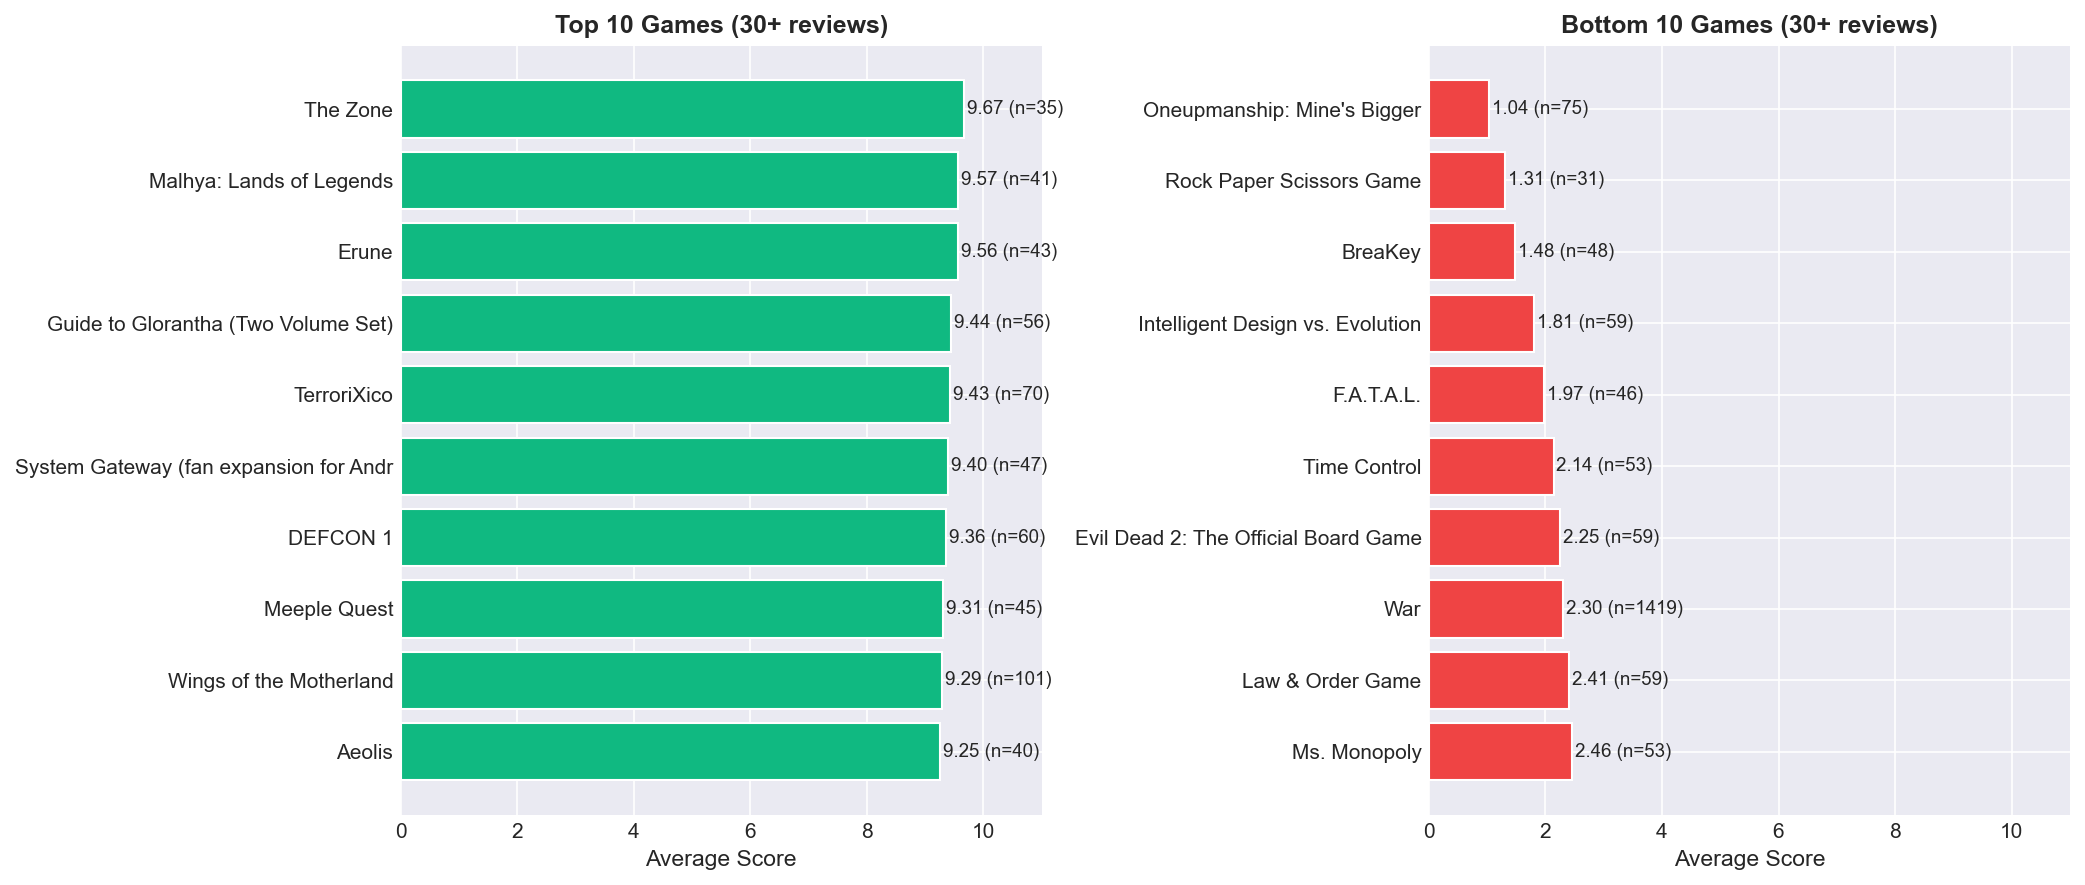

In [19]:
df_reliable = df_unique[df_unique['Number of Reviews'] >= 30].copy()
print(f'Reliable subset (30+ reviews): {len(df_reliable):,} games')

top10 = df_reliable.nlargest(10, 'Average Score')[['Name', 'Average Score', 'Number of Reviews']]
bot10 = df_reliable.nsmallest(10, 'Average Score')[['Name', 'Average Score', 'Number of Reviews']]

print('\nTop 10 (30+ reviews):')
print(top10.to_string(index=False))
print('\nBottom 10 (30+ reviews):')
print(bot10.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_sorted = top10.iloc[::-1]
axes[0].barh(top_sorted['Name'].str[:38], top_sorted['Average Score'],
             color='#10B981', edgecolor='white')
for i, (s, n) in enumerate(zip(top_sorted['Average Score'], top_sorted['Number of Reviews'])):
    axes[0].text(s + 0.05, i, f'{s:.2f} (n={n})', va='center', fontsize=9)
axes[0].set_xlim(0, 11)
axes[0].set_title('Top 10 Games (30+ reviews)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Score', fontsize=11)

bot_sorted = bot10.iloc[::-1]
axes[1].barh(bot_sorted['Name'].str[:38], bot_sorted['Average Score'],
             color='#EF4444', edgecolor='white')
for i, (s, n) in enumerate(zip(bot_sorted['Average Score'], bot_sorted['Number of Reviews'])):
    axes[1].text(s + 0.05, i, f'{s:.2f} (n={n})', va='center', fontsize=9)
axes[1].set_xlim(0, 11)
axes[1].set_title('Bottom 10 Games (30+ reviews)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Score', fontsize=11)

plt.tight_layout()
plt.savefig('eda_charts/M11_top_bottom_games.png', dpi=300, bbox_inches='tight')
plt.show()

### Finding 10: Top Games Are Niche TTRPGs; Bottom Games Are Joke/Protest Games

**Observations:**
- Top 10 are nearly all TTRPG titles (The Zone, Malhya, Erune, Glorantha, TerroriXico) with modest review counts (30–70) — high enthusiasm from a small dedicated audience
- Bottom 10 include intentional novelties: Rock Paper Scissors Game (1.31), Oneupmanship (1.04), Intelligent Design vs. Evolution (1.81), F.A.T.A.L. (1.97). "War" (the card game) at 2.30 with 1,419 reviews is the most-reviewed bottom title
- Pattern matches BGG: hobbyist platforms reward depth and punish triviality

**For the presentation:** This slide doubles as a sanity check — both lists make sense to anyone familiar with hobby gaming, which builds audience trust before you show any model numbers.

---
## 11. Summary of Key Findings

These are the takeaways most useful for the presentation and write-up. Each one is already supported by a chart above.

| # | Finding | Chart |
|---|---------|-------|
| 1 | Dataset is clean: 10k rows × 355 cols (4 meta + 159 Cat + 192 Mech), all binary, no missing | — |
| 2 | 51% of rows are duplicates — intentional class-balancing via oversampling | — |
| 3 | Oversampling pulls mean score from 6.59 → 5.38 and flattens the 10-pt distribution | M01 |
| 4 | Merge + balance solves the BGG imbalance: baseline 3-class accuracy drops from ~0.62 to ~0.36 | M02 |
| 5 | Score reliability is review-count dependent: std drops from 2.7 (1–5 reviews) to 1.0 (100+) | M03 |
| 6 | Hits use 48% more words than Flops on average (207 vs 140) — text signal is real | M04, M05 |
| 7 | Categories carry strong score signal: Wargame, Fantasy ~27% hit rate vs Children's Game ~1% | M06, M07 |
| 8 | TTRPG-specific mechanics (Core Rules, Campaign Setting, Sourcebook) have the highest hit rates | M08, M09 |
| 9 | Encoded matrices are >98% sparse — explains the SVD blowup the team saw with full features | M10 |
| 10 | Top games are niche TTRPGs; bottom games are intentional novelties — hobbyist audience bias | M11 |

### Decisions That Follow from This EDA

1. **Use the deduplicated view for population-level claims** in the write-up. Use the oversampled view only when describing what the model trains on.
2. **Keep description-only as the primary feature source** — the sparsity of categorical features (Finding 9) plus the strong word-count signal (Finding 6) supports this.
3. **Categories and mechanics belong in an appendix model**, not the main pipeline — their feature signal is real (Findings 7–8) but the sparsity hurts.
4. **Add a Limitations note** about platform bias: TTRPG mechanics having higher hit rates (Finding 8) shows that RPGGeek users score more generously than BGG users. The model inherits this bias.
5. **Filter to 30+ reviews when displaying top/bottom games** in any slide (Finding 5).
6. **Baseline metrics should be computed on the same view as the model** — quote the oversampled-view baseline (lower) when reporting RMSE improvement, since that's what the model is fit on.